# Week 15 — Wednesday (Jul 3): Pix2Pix & CycleGAN

## Learning Objectives
- Understand conditional GANs — generating an output image conditioned on an input image, not random noise
- Understand the PatchGAN discriminator and why it works better than a single real/fake scalar
- Implement Pix2Pix (paired image-to-image translation) with a combined adversarial + L1 loss
- Understand cycle-consistency loss and how CycleGAN removes the need for paired data
- Implement a toy CycleGAN with two generators and two discriminators

## Key Concepts
1. **Conditional GAN (cGAN)** — G(x, z) → y, D(x, y) judges whether y is a real/fake match for x
2. **PatchGAN** — discriminator outputs an N×N grid of real/fake scores, one per image patch, instead of a single scalar
3. **Pix2Pix loss** — `L = L_adv(G, D) + λ·L1(G(x), y)` — adversarial loss for sharp detail, L1 for correct low-frequency structure
4. **CycleGAN** — two generators `G: X→Y` and `F: Y→X`, two discriminators `D_X`, `D_Y`
5. **Cycle-consistency loss** — `F(G(x)) ≈ x` and `G(F(y)) ≈ y`, enforced with L1, so translation is learned without paired examples


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Week 15 - Wednesday: Pix2Pix & CycleGAN')

PyTorch 2.12.0+cpu | Device: cpu
Week 15 - Wednesday: Pix2Pix & CycleGAN


## Section 1: Conditional GANs & PatchGAN

A **vanilla GAN** generates an image from pure noise `z`. A **conditional GAN** instead generates
an image `y` from an input image `x`: `G(x, z) → y`. The discriminator also sees the pair `(x, y)`
and asks *"is y a plausible translation of x?"* rather than *"is y a real image?"*.

**Why PatchGAN?** A single real/fake scalar for the whole image only penalises *global* structure.
Pix2Pix instead uses a fully-convolutional discriminator whose output is an `N×N` grid — each
value judges one local patch of the image. This:
- Focuses the discriminator on **high-frequency detail** (texture, sharp edges) — the L1 loss
  already handles low-frequency correctness (overall colour/shape)
- Has fewer parameters than a discriminator over the whole image
- Can be applied to images of any size (fully convolutional, no FC layers)


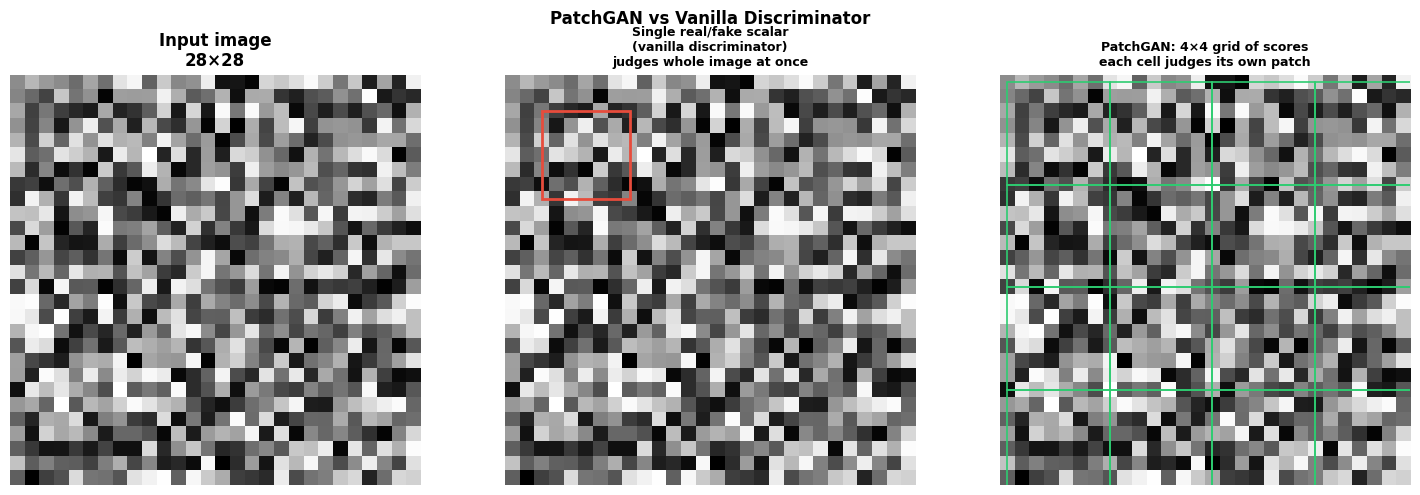

Saved patchgan_receptive_field.png


In [2]:
# ── Visualise PatchGAN receptive fields ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

np.random.seed(0)
img = np.random.rand(28, 28)

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Input image\n28×28', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img, cmap='gray')
patch = plt.Rectangle((2, 2), 6, 6, edgecolor='#e74c3c', facecolor='none', lw=2)
axes[1].add_patch(patch)
axes[1].set_title('Single real/fake scalar\n(vanilla discriminator)\njudges whole image at once',
                   fontweight='bold', fontsize=9)
axes[1].axis('off')

axes[2].imshow(img, cmap='gray')
for r in range(0, 28, 7):
    for c in range(0, 28, 7):
        rect = plt.Rectangle((c, r), 7, 7, edgecolor='#2ecc71', facecolor='none', lw=1.2)
        axes[2].add_patch(rect)
axes[2].set_title('PatchGAN: 4×4 grid of scores\neach cell judges its own patch',
                   fontweight='bold', fontsize=9)
axes[2].axis('off')

plt.suptitle('PatchGAN vs Vanilla Discriminator', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('patchgan_receptive_field.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved patchgan_receptive_field.png')

## Section 2: Pix2Pix — Paired Translation (Edge → Digit)

Pix2Pix needs **paired** data `(x, y)`. Real Pix2Pix uses datasets like edges→shoes or maps→aerial
photos. To keep training fast on CPU we build an equivalent paired task from MNIST: the input `x`
is a **Sobel edge map** of a digit, the target `y` is the **original digit image** — the network
must learn to "fill in" a plausible digit from just its edges, exactly like edges→shoes.


In [3]:
# ── Build paired edge→digit dataset from MNIST ─────────────────────────────────
N_SAMPLES = 1500
N_EPOCHS_P2P = 6
BATCH_SIZE = 32
LAMBDA_L1 = 100

tf = transforms.Compose([transforms.Resize(32), transforms.ToTensor()])
mnist = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=tf)
subset = Subset(mnist, list(range(N_SAMPLES)))

def sobel_edges(x):
    # x: (B,1,H,W) in [0,1]
    kx = torch.tensor([[-1.,0.,1.],[-2.,0.,2.],[-1.,0.,1.]]).view(1,1,3,3)
    ky = kx.transpose(2,3)
    gx = F.conv2d(x, kx, padding=1)
    gy = F.conv2d(x, ky, padding=1)
    mag = torch.sqrt(gx**2 + gy**2 + 1e-8)
    mag = mag / mag.amax(dim=(2,3), keepdim=True).clamp(min=1e-6)
    return mag

loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
xb, _ = next(iter(loader))
edges_demo = sobel_edges(xb)
print(f'Paired dataset: {len(subset)} samples | input=edge map, target=digit, size {tuple(xb.shape[2:])}')

Paired dataset: 1500 samples | input=edge map, target=digit, size (32, 32)


In [4]:
# ── U-Net-lite Generator (encoder-decoder with skip connections) ──────────────
class UNetLiteGenerator(nn.Module):
    """Small U-Net: 32x32 edge map -> 32x32 digit, with skip connections."""
    def __init__(self, in_ch=1, out_ch=1, base=32):
        super().__init__()
        self.e1 = nn.Sequential(nn.Conv2d(in_ch, base, 4, 2, 1), nn.LeakyReLU(0.2))       # 16x16
        self.e2 = nn.Sequential(nn.Conv2d(base, base*2, 4, 2, 1), nn.BatchNorm2d(base*2), nn.LeakyReLU(0.2))  # 8x8
        self.e3 = nn.Sequential(nn.Conv2d(base*2, base*4, 4, 2, 1), nn.BatchNorm2d(base*4), nn.LeakyReLU(0.2)) # 4x4
        self.d1 = nn.Sequential(nn.ConvTranspose2d(base*4, base*2, 4, 2, 1), nn.BatchNorm2d(base*2), nn.ReLU())  # 8x8
        self.d2 = nn.Sequential(nn.ConvTranspose2d(base*4, base, 4, 2, 1), nn.BatchNorm2d(base), nn.ReLU())      # 16x16 (skip)
        self.d3 = nn.ConvTranspose2d(base*2, out_ch, 4, 2, 1)                                                    # 32x32 (skip)

    def forward(self, x):
        e1 = self.e1(x); e2 = self.e2(e1); e3 = self.e3(e2)
        d1 = self.d1(e3)
        d2 = self.d2(torch.cat([d1, e2], dim=1))
        d3 = self.d3(torch.cat([d2, e1], dim=1))
        return torch.sigmoid(d3)

class PatchDiscriminator(nn.Module):
    """PatchGAN: takes concatenated (x, y) -> grid of real/fake scores."""
    def __init__(self, in_ch=2, base=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base, 4, 2, 1), nn.LeakyReLU(0.2),          # 16x16
            nn.Conv2d(base, base*2, 4, 2, 1), nn.BatchNorm2d(base*2), nn.LeakyReLU(0.2),  # 8x8
            nn.Conv2d(base*2, base*4, 4, 2, 1), nn.BatchNorm2d(base*4), nn.LeakyReLU(0.2), # 4x4
            nn.Conv2d(base*4, 1, 4, 1, 1)                                 # patch scores
        )
    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))

G_p2p = UNetLiteGenerator().to(DEVICE)
D_p2p = PatchDiscriminator().to(DEVICE)
print(f'Generator params: {sum(p.numel() for p in G_p2p.parameters()):,}')
print(f'PatchGAN Discriminator params: {sum(p.numel() for p in D_p2p.parameters()):,}')

Generator params: 362,881
PatchGAN Discriminator params: 167,521


In [5]:
# ── Train Pix2Pix: adversarial + L1 loss ───────────────────────────────────────
opt_G = torch.optim.Adam(G_p2p.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D_p2p.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce = nn.BCEWithLogitsLoss()
l1  = nn.L1Loss()

history_p2p = {'d_loss': [], 'g_loss': [], 'l1_loss': []}
for epoch in range(N_EPOCHS_P2P):
    d_losses, g_losses, l1_losses = [], [], []
    for real_y, _ in loader:
        real_y = real_y.to(DEVICE)
        real_x = sobel_edges(real_y)

        # ---- Discriminator ----
        with torch.no_grad():
            fake_y = G_p2p(real_x)
        d_real = D_p2p(real_x, real_y)
        d_fake = D_p2p(real_x, fake_y)
        d_loss = bce(d_real, torch.ones_like(d_real)) + bce(d_fake, torch.zeros_like(d_fake))
        opt_D.zero_grad(); d_loss.backward(); opt_D.step()

        # ---- Generator ----
        fake_y = G_p2p(real_x)
        d_fake_for_g = D_p2p(real_x, fake_y)
        g_adv = bce(d_fake_for_g, torch.ones_like(d_fake_for_g))
        g_l1  = l1(fake_y, real_y)
        g_loss = g_adv + LAMBDA_L1 * g_l1
        opt_G.zero_grad(); g_loss.backward(); opt_G.step()

        d_losses.append(d_loss.item()); g_losses.append(g_adv.item()); l1_losses.append(g_l1.item())

    history_p2p['d_loss'].append(np.mean(d_losses))
    history_p2p['g_loss'].append(np.mean(g_losses))
    history_p2p['l1_loss'].append(np.mean(l1_losses))
    print(f'Epoch {epoch+1}/{N_EPOCHS_P2P} | D: {np.mean(d_losses):.3f} | G_adv: {np.mean(g_losses):.3f} | L1: {np.mean(l1_losses):.4f}')

Epoch 1/6 | D: 0.490 | G_adv: 2.213 | L1: 0.2910


Epoch 2/6 | D: 0.059 | G_adv: 4.040 | L1: 0.1663


Epoch 3/6 | D: 0.122 | G_adv: 4.450 | L1: 0.1106


Epoch 4/6 | D: 0.073 | G_adv: 4.074 | L1: 0.0798


Epoch 5/6 | D: 0.393 | G_adv: 3.140 | L1: 0.0589


Epoch 6/6 | D: 0.435 | G_adv: 2.657 | L1: 0.0464


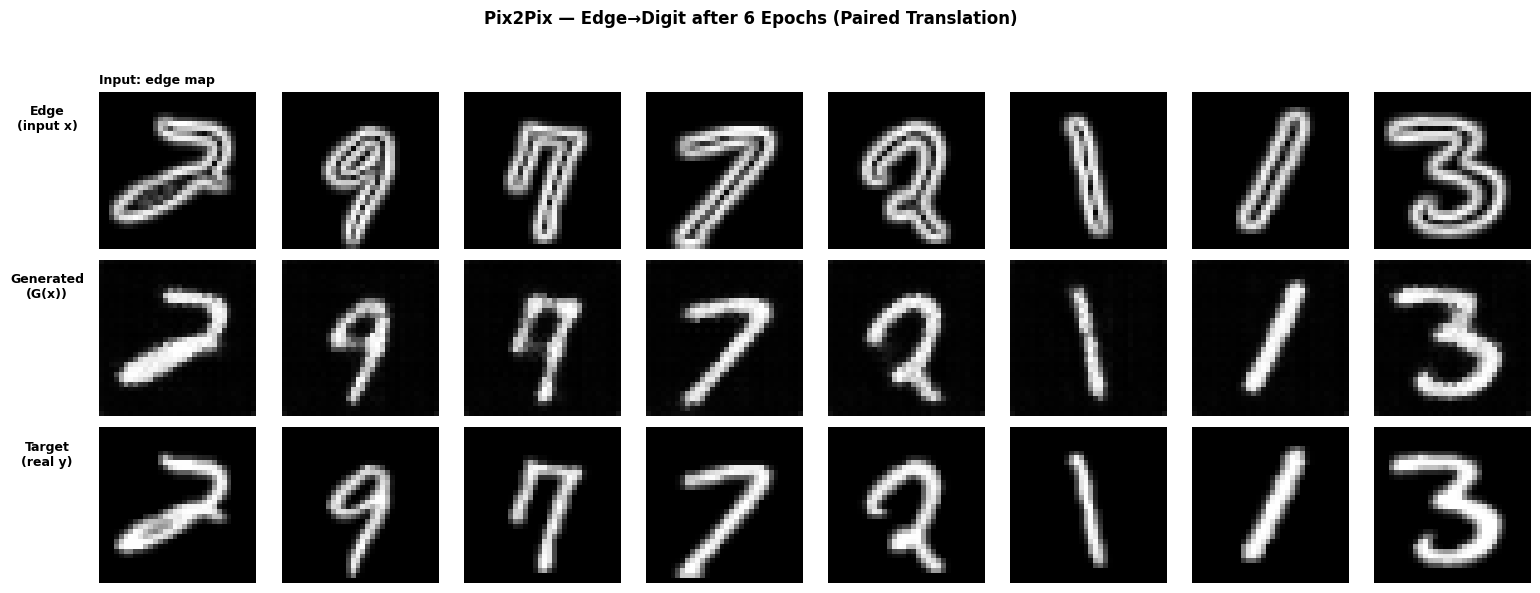

Saved pix2pix_generated.png


In [6]:
# ── Pix2Pix results: edge -> generated -> target ───────────────────────────────
G_p2p.eval()
with torch.no_grad():
    sample_y, _ = next(iter(loader))
    sample_y = sample_y[:8].to(DEVICE)
    sample_x = sobel_edges(sample_y)
    sample_fake = G_p2p(sample_x)

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i in range(8):
    axes[0,i].imshow(sample_x[i,0].cpu().numpy(), cmap='gray'); axes[0,i].axis('off')
    axes[1,i].imshow(sample_fake[i,0].cpu().numpy(), cmap='gray'); axes[1,i].axis('off')
    axes[2,i].imshow(sample_y[i,0].cpu().numpy(), cmap='gray'); axes[2,i].axis('off')
axes[0,0].set_title('Input: edge map', loc='left', fontweight='bold', fontsize=9)
fig.text(0.06, 0.78, 'Edge\n(input x)', ha='center', fontweight='bold', fontsize=9)
fig.text(0.06, 0.5, 'Generated\n(G(x))', ha='center', fontweight='bold', fontsize=9)
fig.text(0.06, 0.22, 'Target\n(real y)', ha='center', fontweight='bold', fontsize=9)
plt.suptitle(f'Pix2Pix — Edge→Digit after {N_EPOCHS_P2P} Epochs (Paired Translation)', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0.08,0,1,0.95])
plt.savefig('pix2pix_generated.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved pix2pix_generated.png')

## Section 3: CycleGAN — Unpaired Translation

Pix2Pix needs **paired** `(x, y)` examples, which are expensive to collect (e.g. the exact same
scene photographed and hand-drawn as a map). **CycleGAN** removes this requirement by training on
two **unpaired** collections of images from domain `X` and domain `Y`.

Two generators are trained together:
- `G: X → Y` and `F: Y → X`

Since there's no ground-truth pair to compare against, CycleGAN instead enforces
**cycle-consistency**: translating there and back should return the original image.
```
x → G(x) → F(G(x)) ≈ x        (forward cycle)
y → F(y) → G(F(y)) ≈ y        (backward cycle)
```
`L_cycle = ||F(G(x)) - x||₁ + ||G(F(y)) - y||₁`, combined with an adversarial loss for each
generator/discriminator pair (`D_X` catches fake `x`s, `D_Y` catches fake `y`s).

We use two unpaired MNIST-derived domains: **X = normal digits**, **Y = inverted (negative)
digits** — sampled independently so no image is paired with its "partner".


In [7]:
# ── Build unpaired domains ─────────────────────────────────────────────────────
N_EPOCHS_CYC = 5
idx_all = list(range(N_SAMPLES))
idx_x = idx_all[:N_SAMPLES//2]
idx_y = idx_all[N_SAMPLES//2:]
loader_x = DataLoader(Subset(mnist, idx_x), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
loader_y = DataLoader(Subset(mnist, idx_y), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

def to_domain_y(img):
    return 1.0 - img  # domain Y: inverted digits (unpaired w.r.t. domain X samples)

G_XY = UNetLiteGenerator().to(DEVICE)   # normal -> inverted
G_YX = UNetLiteGenerator().to(DEVICE)   # inverted -> normal
D_X  = PatchDiscriminator(in_ch=2).to(DEVICE)   # forward concatenates (img, img) -> 2 channels
D_Y  = PatchDiscriminator(in_ch=2).to(DEVICE)

opt_G_cyc = torch.optim.Adam(list(G_XY.parameters()) + list(G_YX.parameters()), lr=2e-4, betas=(0.5,0.999))
opt_D_cyc = torch.optim.Adam(list(D_X.parameters()) + list(D_Y.parameters()), lr=2e-4, betas=(0.5,0.999))
LAMBDA_CYC = 10
print('CycleGAN: domain X = normal digits, domain Y = inverted digits (unpaired)')

CycleGAN: domain X = normal digits, domain Y = inverted digits (unpaired)


In [8]:
# ── Train CycleGAN: adversarial (per domain) + cycle-consistency loss ─────────
history_cyc = {'g_loss': [], 'cycle_loss': [], 'd_loss': []}
for epoch in range(N_EPOCHS_CYC):
    g_losses, cyc_losses, d_losses = [], [], []
    for (real_x, _), (real_y_src, _) in zip(loader_x, loader_y):
        real_x = real_x.to(DEVICE)
        real_y = to_domain_y(real_y_src.to(DEVICE))   # unpaired domain-Y sample

        # ---- Discriminators (single class score per patch, real domain images only) ----
        fake_y = G_XY(real_x).detach()
        fake_x = G_YX(real_y).detach()
        dx_real, dx_fake = D_X(real_x, real_x), D_X(fake_x, fake_x)
        dy_real, dy_fake = D_Y(real_y, real_y), D_Y(fake_y, fake_y)
        d_x_loss = bce(dx_real, torch.ones_like(dx_real)) + bce(dx_fake, torch.zeros_like(dx_fake))
        d_y_loss = bce(dy_real, torch.ones_like(dy_real)) + bce(dy_fake, torch.zeros_like(dy_fake))
        d_loss = d_x_loss + d_y_loss
        opt_D_cyc.zero_grad(); d_loss.backward(); opt_D_cyc.step()

        # ---- Generators: adversarial + cycle-consistency ----
        fake_y = G_XY(real_x)
        fake_x = G_YX(real_y)
        rec_x  = G_YX(fake_y)   # F(G(x))
        rec_y  = G_XY(fake_x)   # G(F(y))

        dy_fake_g, dx_fake_g = D_Y(fake_y, fake_y), D_X(fake_x, fake_x)
        g_adv = bce(dy_fake_g, torch.ones_like(dy_fake_g)) + bce(dx_fake_g, torch.ones_like(dx_fake_g))
        cyc_loss = l1(rec_x, real_x) + l1(rec_y, real_y)
        g_loss = g_adv + LAMBDA_CYC * cyc_loss
        opt_G_cyc.zero_grad(); g_loss.backward(); opt_G_cyc.step()

        g_losses.append(g_adv.item()); cyc_losses.append(cyc_loss.item()); d_losses.append(d_loss.item())

    history_cyc['g_loss'].append(np.mean(g_losses))
    history_cyc['cycle_loss'].append(np.mean(cyc_losses))
    history_cyc['d_loss'].append(np.mean(d_losses))
    print(f'Epoch {epoch+1}/{N_EPOCHS_CYC} | D: {np.mean(d_losses):.3f} | G_adv: {np.mean(g_losses):.3f} | Cycle L1: {np.mean(cyc_losses):.4f}')

Epoch 1/5 | D: 2.178 | G_adv: 2.120 | Cycle L1: 0.7273


Epoch 2/5 | D: 1.267 | G_adv: 3.513 | Cycle L1: 0.5147


Epoch 3/5 | D: 1.224 | G_adv: 3.886 | Cycle L1: 0.4188


Epoch 4/5 | D: 1.484 | G_adv: 3.679 | Cycle L1: 0.3244


Epoch 5/5 | D: 1.929 | G_adv: 3.119 | Cycle L1: 0.2400


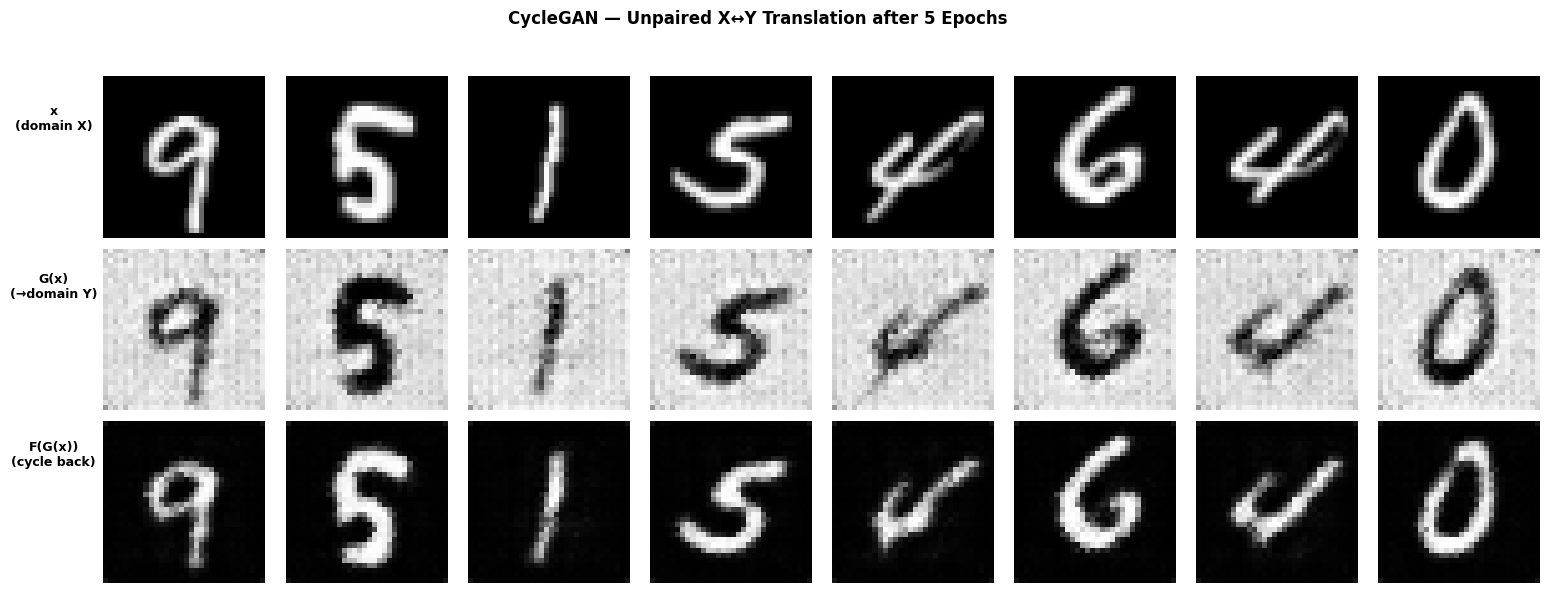

Saved cyclegan_translation.png


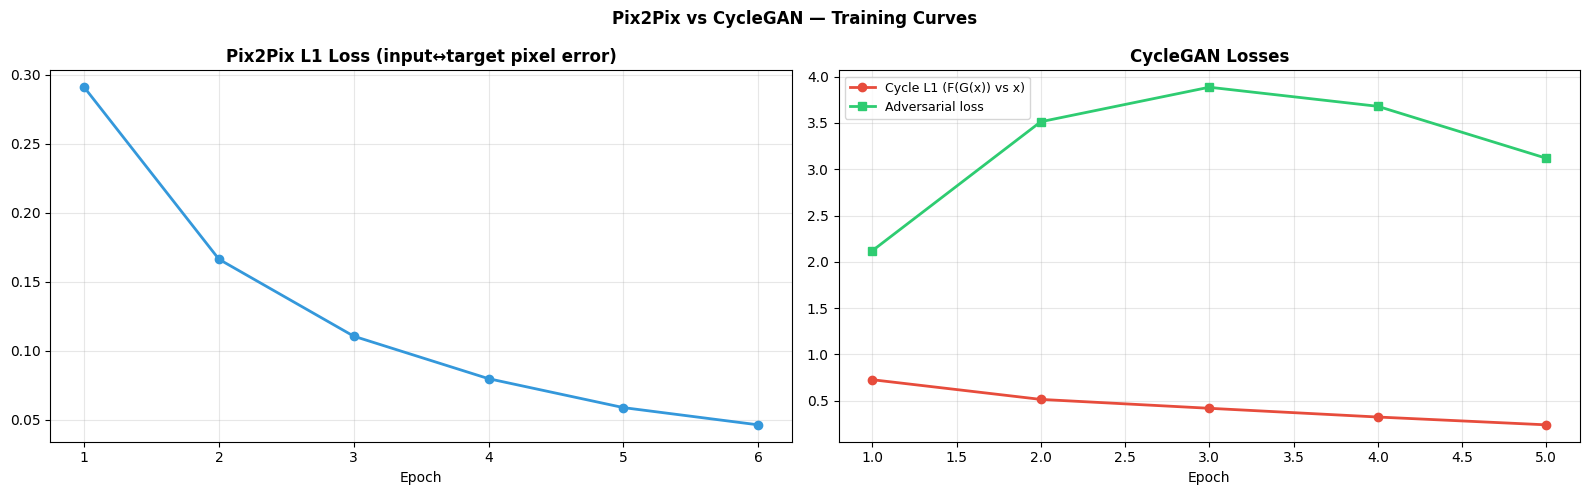

Saved cycle_consistency.png


In [9]:
# ── CycleGAN results: X -> Y -> X (and cycle-consistency check) ───────────────
G_XY.eval(); G_YX.eval()
with torch.no_grad():
    real_x_s, _ = next(iter(loader_x))
    real_x_s = real_x_s[:8].to(DEVICE)
    fake_y_s = G_XY(real_x_s)
    rec_x_s  = G_YX(fake_y_s)

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i in range(8):
    axes[0,i].imshow(real_x_s[i,0].cpu().numpy(), cmap='gray'); axes[0,i].axis('off')
    axes[1,i].imshow(fake_y_s[i,0].cpu().numpy(), cmap='gray'); axes[1,i].axis('off')
    axes[2,i].imshow(rec_x_s[i,0].cpu().numpy(), cmap='gray'); axes[2,i].axis('off')
fig.text(0.06, 0.78, 'x\n(domain X)', ha='center', fontweight='bold', fontsize=9)
fig.text(0.06, 0.5, 'G(x)\n(→domain Y)', ha='center', fontweight='bold', fontsize=9)
fig.text(0.06, 0.22, 'F(G(x))\n(cycle back)', ha='center', fontweight='bold', fontsize=9)
plt.suptitle(f'CycleGAN — Unpaired X↔Y Translation after {N_EPOCHS_CYC} Epochs', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0.08,0,1,0.95])
plt.savefig('cyclegan_translation.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved cyclegan_translation.png')

# Cycle-consistency error plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ep_p2p = range(1, N_EPOCHS_P2P+1)
axes[0].plot(ep_p2p, history_p2p['l1_loss'], color='#3498db', lw=2, marker='o')
axes[0].set_title('Pix2Pix L1 Loss (input↔target pixel error)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].grid(True, alpha=0.3)

ep_cyc = range(1, N_EPOCHS_CYC+1)
axes[1].plot(ep_cyc, history_cyc['cycle_loss'], color='#e74c3c', lw=2, marker='o', label='Cycle L1 (F(G(x)) vs x)')
axes[1].plot(ep_cyc, history_cyc['g_loss'], color='#2ecc71', lw=2, marker='s', label='Adversarial loss')
axes[1].set_title('CycleGAN Losses', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Pix2Pix vs CycleGAN — Training Curves', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cycle_consistency.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved cycle_consistency.png')

## Key Takeaways

| Concept | Summary |
|---------|--------|
| **Conditional GAN** | Generator conditions on an input image `x`, not just noise — `G(x,z)→y` |
| **PatchGAN** | Discriminator outputs a grid of patch scores instead of one scalar — sharper high-frequency detail |
| **Pix2Pix loss** | `L_adv + λ·L1` — adversarial loss for realism, L1 for correct low-frequency structure (needs **paired** data) |
| **CycleGAN** | Two generators (`G: X→Y`, `F: Y→X`) + two discriminators — no paired data required |
| **Cycle-consistency** | `F(G(x))≈x` and `G(F(y))≈y`, enforced with L1 — the core trick that makes unpaired translation work |
| **When to use which** | Paired data available → Pix2Pix (simpler, more stable); only unpaired collections → CycleGAN |
